### Import Events

In [ ]:
import boto3
import json
import pandas as pd

s3 = boto3.client("s3")
bucket = "siem-data"

rows = []

paginator = s3.get_paginator("list_objects_v2")

for page in paginator.paginate(Bucket=bucket, Prefix="events/"):
    for obj in page.get("Contents", []):
        key = obj["Key"]

        body = s3.get_object(Bucket=bucket, Key=key)
        data = json.loads(body["Body"].read())

        rows.append({
            "username": data.get("username"),
            "event_name": data.get("event_name"),
            "source_ip": data.get("source_ip"),
            "severity": data.get("severity"),
            "team": data.get("team"),
            "timestamp": data.get("timestamp")
        })

df = pd.DataFrame(rows)

print(df.shape)
print(df.head())

### 1. Events over time (core SIEM timeline)

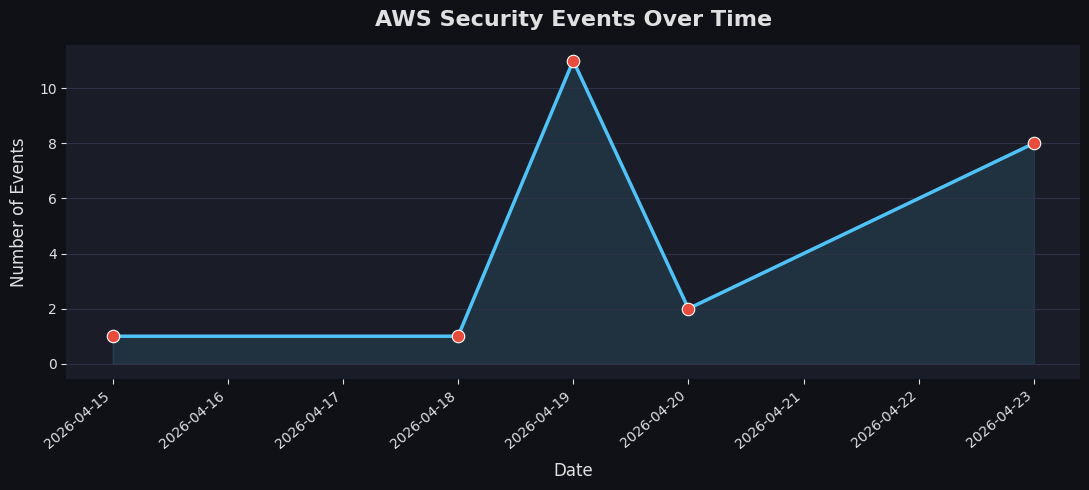

In [2]:
import matplotlib.pyplot as plt
import numpy as np

DARK_BG  = "#0f1117"
PANEL_BG = "#1a1d27"
ACCENT   = "#4fc3f7"
TEXT     = "#e0e0e0"
GRID     = "#2e3148"

plt.rcParams.update({
    "figure.facecolor": DARK_BG,
    "axes.facecolor":   PANEL_BG,
    "axes.edgecolor":   GRID,
    "axes.labelcolor":  TEXT,
    "xtick.color":      TEXT,
    "ytick.color":      TEXT,
    "text.color":       TEXT,
    "grid.color":       GRID,
    "grid.linewidth":   0.8,
})

df["timestamp"] = pd.to_datetime(df["timestamp"])
daily = df.groupby(df["timestamp"].dt.date).size()

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(daily.index, daily.values, marker="o", linewidth=2.5,
        color=ACCENT, markersize=9, markerfacecolor="#e74c3c",
        markeredgecolor="white", markeredgewidth=0.8)
ax.fill_between(daily.index, daily.values, alpha=0.12, color=ACCENT)

ax.set_title("AWS Security Events Over Time", fontsize=16, fontweight="bold", pad=14)
ax.set_xlabel("Date", fontsize=12, labelpad=8)
ax.set_ylabel("Number of Events", fontsize=12, labelpad=8)
ax.grid(True, axis="y")
ax.spines[["top", "right", "left", "bottom"]].set_visible(False)
plt.xticks(rotation=40, ha="right")
plt.tight_layout()
plt.show()


### 2. Event type distribution

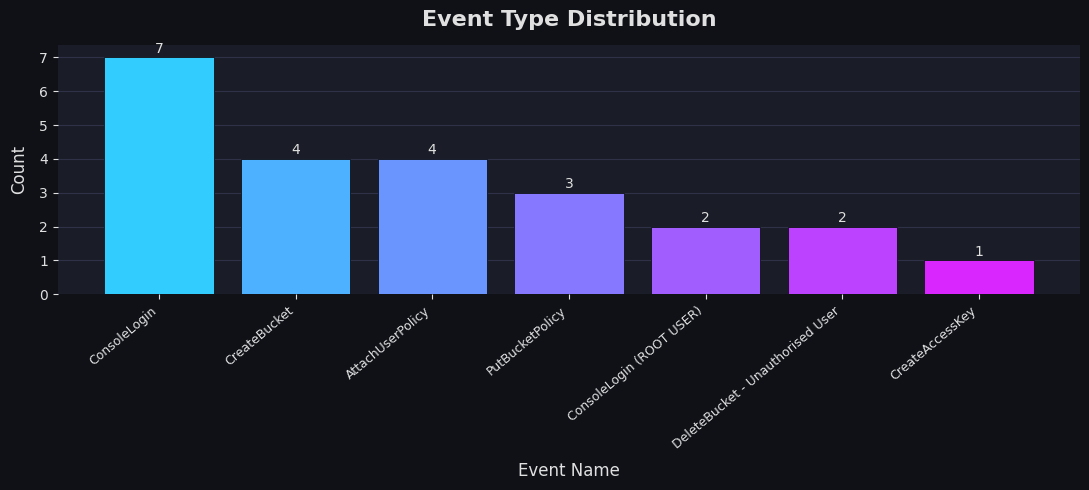

In [3]:
counts = df["event_name"].value_counts()
colors = plt.cm.cool(np.linspace(0.2, 0.85, len(counts)))

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(counts.index, counts.values, color=colors, edgecolor=DARK_BG, linewidth=0.6)

for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
            str(val), ha="center", va="bottom", fontsize=10, color=TEXT)

ax.set_title("Event Type Distribution", fontsize=16, fontweight="bold", pad=14)
ax.set_xlabel("Event Name", fontsize=12, labelpad=8)
ax.set_ylabel("Count", fontsize=12, labelpad=8)
ax.spines[["top", "right", "left", "bottom"]].set_visible(False)
ax.grid(True, axis="y")
ax.set_axisbelow(True)
plt.xticks(rotation=40, ha="right", fontsize=9)
plt.tight_layout()
plt.show()


### 3. Severity breakdown (SIEM risk view)

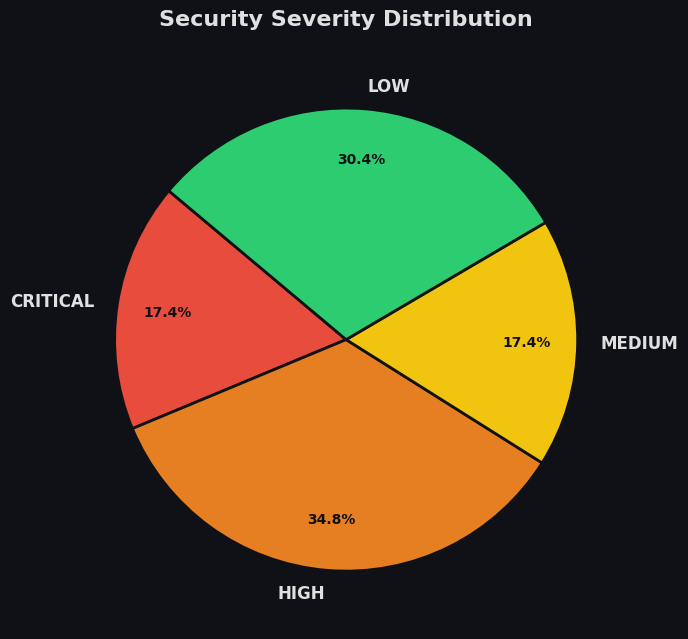

In [4]:
severity_order  = ["CRITICAL", "HIGH", "MEDIUM", "LOW"]
severity_colors = {"CRITICAL": "#e74c3c", "HIGH": "#e67e22", "MEDIUM": "#f1c40f", "LOW": "#2ecc71"}

sev_counts = df["severity"].value_counts().reindex(
    [s for s in severity_order if s in df["severity"].values]
)
colors = [severity_colors[s] for s in sev_counts.index]

fig, ax = plt.subplots(figsize=(7, 7))
wedges, texts, autotexts = ax.pie(
    sev_counts.values,
    labels=sev_counts.index,
    autopct="%1.1f%%",
    colors=colors,
    startangle=140,
    wedgeprops={"edgecolor": DARK_BG, "linewidth": 2},
    pctdistance=0.78,
)
for t in texts:
    t.set(fontsize=12, color=TEXT, fontweight="bold")
for at in autotexts:
    at.set(fontsize=10, color=DARK_BG, fontweight="bold")

ax.set_title("Security Severity Distribution", fontsize=16, fontweight="bold", pad=18)
plt.tight_layout()
plt.show()


### 4. Top users (risk actors)

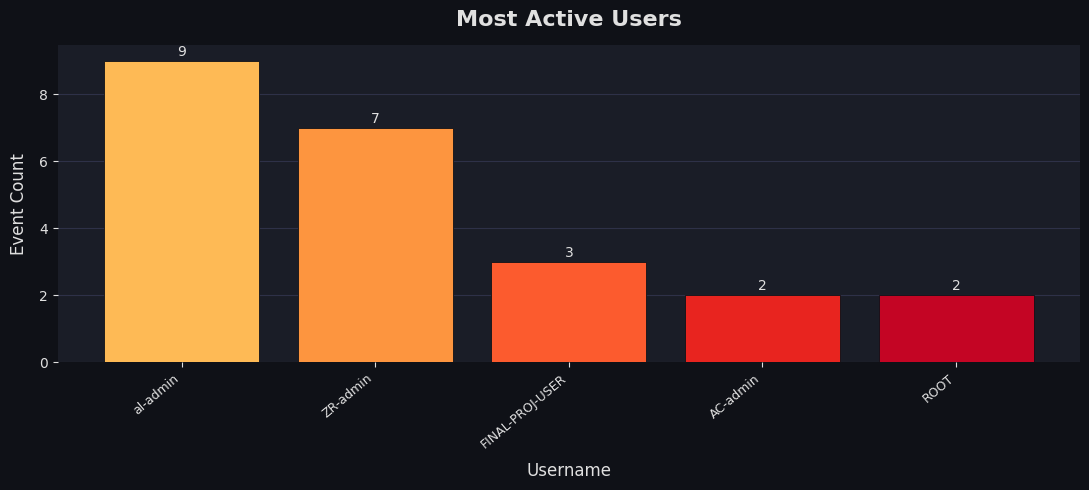

In [5]:
counts = df["username"].value_counts()
colors = plt.cm.YlOrRd(np.linspace(0.35, 0.85, len(counts)))

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(counts.index, counts.values, color=colors, edgecolor=DARK_BG, linewidth=0.6)

for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
            str(val), ha="center", va="bottom", fontsize=10, color=TEXT)

ax.set_title("Most Active Users", fontsize=16, fontweight="bold", pad=14)
ax.set_xlabel("Username", fontsize=12, labelpad=8)
ax.set_ylabel("Event Count", fontsize=12, labelpad=8)
ax.spines[["top", "right", "left", "bottom"]].set_visible(False)
ax.grid(True, axis="y")
ax.set_axisbelow(True)
plt.xticks(rotation=40, ha="right", fontsize=9)
plt.tight_layout()
plt.show()


### 5. Source IP activity (anomaly signal)

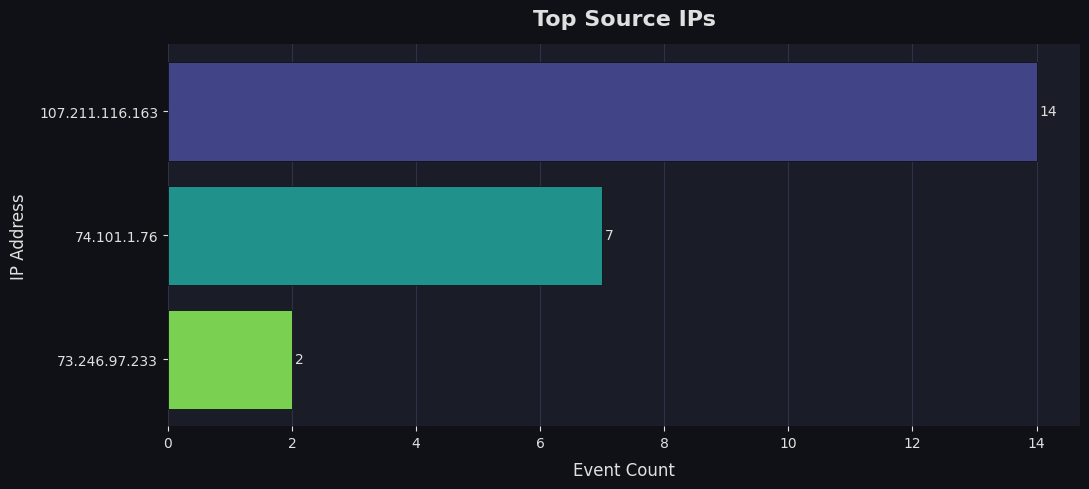

In [6]:
counts = df["source_ip"].value_counts()
colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(counts)))

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.barh(counts.index[::-1], counts.values[::-1], color=colors[::-1],
               edgecolor=DARK_BG, linewidth=0.6)

for bar, val in zip(bars, counts.values[::-1]):
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height() / 2,
            str(val), va="center", fontsize=10, color=TEXT)

ax.set_title("Top Source IPs", fontsize=16, fontweight="bold", pad=14)
ax.set_xlabel("Event Count", fontsize=12, labelpad=8)
ax.set_ylabel("IP Address", fontsize=12, labelpad=8)
ax.spines[["top", "right", "left", "bottom"]].set_visible(False)
ax.grid(True, axis="x")
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()


6. High-risk events only (SIEM focus view)

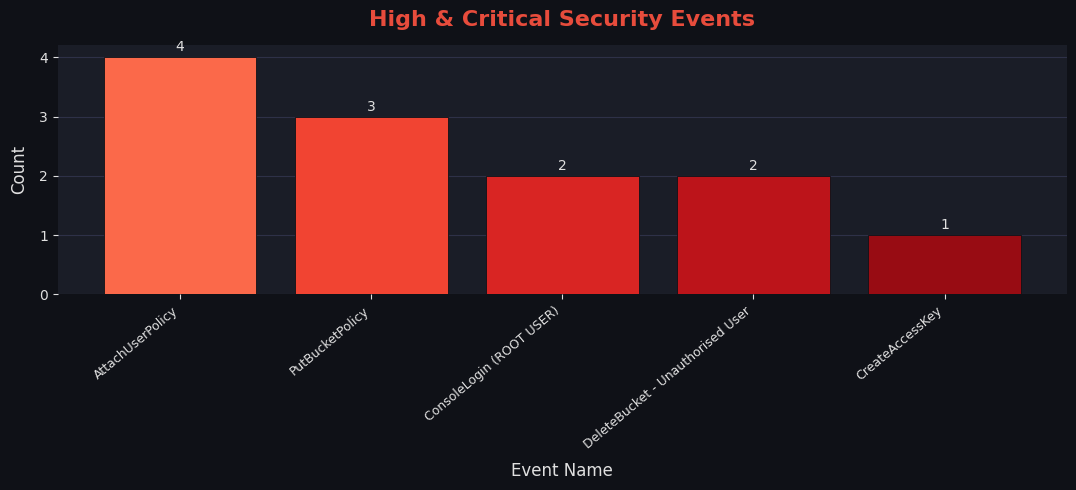

In [7]:
risk_df = df[df["severity"].isin(["HIGH", "CRITICAL"])]
counts  = risk_df["event_name"].value_counts()
colors  = plt.cm.Reds(np.linspace(0.5, 0.9, len(counts)))

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(counts.index, counts.values, color=colors, edgecolor=DARK_BG, linewidth=0.6)

for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
            str(val), ha="center", va="bottom", fontsize=10, color=TEXT)

ax.set_title("High & Critical Security Events", fontsize=16, fontweight="bold",
             pad=14, color="#e74c3c")
ax.set_xlabel("Event Name", fontsize=12, labelpad=8)
ax.set_ylabel("Count", fontsize=12, labelpad=8)
ax.spines[["top", "right", "left", "bottom"]].set_visible(False)
ax.grid(True, axis="y")
ax.set_axisbelow(True)
plt.xticks(rotation=40, ha="right", fontsize=9)
plt.tight_layout()
plt.show()
